In [1]:
import pandas as pd 
import numpy as np 

In [2]:
# Lets load a dataset - Historical data
df1=pd.read_csv(r"C:\Users\Admin\Downloads\Documents\trading datascience project\historical_data.csv")
df1.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [3]:
# Lets get the dataset information 
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [4]:
#Lets check the missing values 
df1.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

##### No missing (null) values were observed in the dataset; all columns contain complete records.


In [15]:
df1.duplicated().sum()

np.int64(0)

##### No duplicate records were identified in the dataset; each observation appears to be unique across the evaluated fields.

### Brief Note on Dataset

The dataset contains 211,224 trade-level records with 16 columns, capturing detailed information about trading activity such as account details, trade size, execution price, fees, and realized profit or loss (PnL). There are no missing values, making the dataset suitable for direct analysis after timestamp conversion.

Key variables include:

Trade details: Coin, Side (Buy/Sell), Execution Price, Size (Tokens & USD)
Performance metrics: Closed PnL, Fee
Identifiers: Account, Order ID, Trade ID, Transaction Hash
Time features: Timestamp IST (human-readable trade time) and Timestamp (Unix time in milliseconds)

The dataset is well-structured for analyzing trading behavior, profitability patterns, trade frequency, leverage characteristics, and daily performance trends, and can be aligned with external sentiment data (Fear vs Greed) for behavioral analysis.

In [5]:
#Let's load second dataset - fear_greed_index
df2=pd.read_csv(r"C:\Users\Admin\Downloads\Documents\trading datascience project\fear_greed_index.csv")
df2.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [7]:
df2.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

##### No missing (null) values were observed in the dataset; all columns contain complete records.

In [8]:
df2.duplicated().sum()

np.int64(0)

##### No duplicate records were identified in the dataset; each observation appears to be unique across the evaluated fields.


### Brief Note on Sentiment Dataset
The dataset contains 2,644 records with 4 columns, representing market sentiment over time. It is structured for time-series analysis and can be aligned with trading data at the daily level.
Key variables include:


timestamp – Unix time indicating when the sentiment value was recorded

value – numerical sentiment score (e.g., Fear–Greed index level)

classification – categorical sentiment label such as Fear, Greed, or Neutral

date – human-readable date for easier merging with trading dataset

The dataset has no missing values and is suitable for analyzing how market sentiment influences trading behavior, performance (PnL), trade frequency, leverage usage, and long/short decisions.

### Data Preprocessing(Dataset Merging)

We will use the Timestamp IST column from the historical dataset (df1) to align it with the sentiment dataset (df2). Before merging, unnecessary timestamp columns will be removed from both datasets. The Timestamp IST column in df1 will be converted to a date field to enable daily-level matching, while the sentiment dataset already contains a date column derived from its timestamp, so no additional conversion is required for df2.

In [9]:
#so lets remove unwanted columns from historical data 
df1=df1.drop('Timestamp',axis=1)

In [10]:
df1.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15


The Timestamp IST column in the historical dataset contains date and time information in the format dd-mm-yyyy hh:mm. To enable daily-level analysis and merge the dataset with sentiment data, the timestamp is converted into a standard date format.

First, the column is converted into a datetime object using the appropriate format. Then, only the date component is extracted, removing the time portion.
This ensures consistency with the sentiment dataset, which already contains a date column, and allows accurate alignment of both datasets on a daily basis.

In [11]:
df1['date'] = pd.to_datetime(
    df1['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

df1['date'] = df1['date'].dt.date


In [12]:
df1.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-12-02


In [13]:
# Let's remove unwanted columns from sentiment dataset as date column is already there which is derived from timestamp
df2=df2.drop('timestamp',axis=1)

In [14]:
df2.head()

,value,classification,date
0,30,Fear,2018-02-01
1,15,Extreme Fear,2018-02-02
2,40,Fear,2018-02-03
3,24,Extreme Fear,2018-02-04
4,11,Extreme Fear,2018-02-05


In [15]:
# sentiment dataset
df2['date'] = pd.to_datetime(df2['date']).dt.date

,value,classification,date
0,30,Fear,2018-02-01
1,15,Extreme Fear,2018-02-02
2,40,Fear,2018-02-03
3,24,Extreme Fear,2018-02-04
4,11,Extreme Fear,2018-02-05
...,...,...,...
2639,54,Neutral,2025-04-28
2640,60,Greed,2025-04-29
2641,56,Greed,2025-04-30
2642,53,Neutral,2025-05-01


#### Merge Historical and Sentiment Datasets

The historical trading dataset (df1) is combined with the sentiment dataset (df2) using the **date** column as the common key. A **left join** is applied to ensure that all trading records are retained, even if sentiment information is missing for certain dates.

This step enriches each trade entry with the corresponding market sentiment classification (e.g., Fear, Greed), enabling analysis of how trader behavior and performance vary under different sentiment conditions.


In [16]:
merged_df = df1.merge(df2, on='date', how='left')

In [17]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-12-02,80.0,Extreme Greed


In [18]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  date              211224 non-null  object 
 16  value             21

In [19]:
merged_df.groupby(
['Account','date']
)['Closed PnL'].sum().reset_index()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000
...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814


#### create daily pnl

In [20]:
daily_pnl = merged_df.groupby(
    ['Account','date']
)['Closed PnL'].sum().reset_index()

daily_pnl.rename(
    columns={'Closed PnL':'daily_pnl'},
    inplace=True
)

Let's group the merged dataset by Account and date to obtain one record per trader per day, and extracts the corresponding market sentiment information for that day. Since the sentiment (classification and value) is the same for all trades on a given date, the code selects the first available sentiment value within each group. The result is a dataframe that links each trader’s daily activity with the market sentiment (Fear or Greed) prevailing on that day, enabling analysis of how sentiment impacts trading behaviour and performance.

In [21]:
sentiment_daily = merged_df.groupby(
    ['Account','date']
).agg({

    'classification':'first',
    'value':'first'

}).reset_index()

In [22]:
sentiment_daily

,Account,date,classification,value
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,76.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,90.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,83.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,94.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,79.0
...,...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,Greed,61.0
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,Neutral,54.0
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,Greed,60.0
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,Greed,56.0


Let's merge the daily profit and loss data (daily_pnl) with the sentiment information (sentiment_daily) using Account and date as common keys. The left join ensures that all trader-day records in daily_pnl are retained while adding the corresponding sentiment classification (Fear or Greed) and sentiment value for that day. This allows each trader’s daily performance to be directly analyzed in relation to the prevailing market sentiment.

In [23]:
daily_pnl = daily_pnl.merge(
    sentiment_daily,
    on=['Account','date'],
    how='left'
)

In [24]:
daily_metrics = daily_pnl

#### Lets create win column in merged_df and then append it in the daily metrics dataframe for further analysis.
Win indicates whether an individual trade was profitable or not. A trade is considered a win when the Closed PnL (profit and loss) is greater than zero, meaning the trader earned a profit from that trade. This variable is typically converted into a binary indicator (1 for profit, 0 for loss) so that the win rate can be calculated as the proportion of profitable trades out of the total trades. The win metric helps measure the consistency and effectiveness of trading decisions under different market sentiment conditions (Fear vs Greed).

In [25]:
merged_df['win'] = merged_df['Closed PnL'] > 0

In [26]:
win_rate_series = merged_df.groupby(
    ['Account','date']
)['win'].mean()

In [27]:
daily_metrics['win_rate'] = win_rate_series.values

In [28]:
daily_metrics

,Account,date,daily_pnl,classification,value,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,Extreme Greed,76.0,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,Extreme Greed,90.0,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,Extreme Greed,83.0,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,Extreme Greed,94.0,0.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,Extreme Greed,79.0,0.444444
...,...,...,...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,Greed,61.0,0.390244
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,Neutral,54.0,0.393023
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,Greed,60.0,0.441242
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,Greed,56.0,0.520000


#### Calculate average trade size & Append to daily_metrics dataframe for further analysis
Average trade size represents the typical capital deployed per trade by a trader on a given day. It is calculated as the mean of the trade value in USD for all trades executed by a trader on that day. This metric helps assess the trader’s risk-taking behaviour and allows comparison of position sizing patterns across different market sentiment conditions (Fear vs Greed).

In [29]:
avg_trade_size = merged_df.groupby(
    ['Account','date']
)['Size USD'].mean().reset_index()

avg_trade_size.rename(
    columns={'Size USD':'avg_trade_size'},
    inplace=True
)

In [30]:
daily_metrics = daily_metrics.merge(
    avg_trade_size,
    on=['Account','date'],
    how='left'
)

In [31]:
daily_metrics

,Account,date,daily_pnl,classification,value,win_rate,avg_trade_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,Extreme Greed,76.0,0.000000,5089.718249
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,Extreme Greed,90.0,0.000000,7976.664412
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,Extreme Greed,83.0,0.000000,23734.500000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,Extreme Greed,94.0,0.000000,28186.666667
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,Extreme Greed,79.0,0.444444,17248.148148
...,...,...,...,...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,Greed,61.0,0.390244,2153.859390
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,Neutral,54.0,0.393023,1495.538419
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,Greed,60.0,0.441242,1939.739989
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,Greed,56.0,0.520000,1748.805333


#### Calculate Number of trades per day & Append to daily_metrics dataframe for further analysis
**Number of trades per day** represents the total trading activity of a trader on a given day. It is calculated by counting how many trades were executed by each trader per day. This metric helps identify how actively traders participate in the market and whether trading frequency changes under different sentiment conditions such as Fear or Greed.

In [32]:
num_trades = merged_df.groupby(
    ['Account','date']
).size().reset_index(name='num_trades')

In [33]:
daily_metrics = daily_metrics.merge(
    num_trades,
    on=['Account','date'],
    how='left'
)

In [34]:
daily_metrics

,Account,date,daily_pnl,classification,value,win_rate,avg_trade_size,num_trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,Extreme Greed,76.0,0.000000,5089.718249,177
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,Extreme Greed,90.0,0.000000,7976.664412,68
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,Extreme Greed,83.0,0.000000,23734.500000,40
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,Extreme Greed,94.0,0.000000,28186.666667,12
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,Extreme Greed,79.0,0.444444,17248.148148,27
...,...,...,...,...,...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,Greed,61.0,0.390244,2153.859390,82
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,Neutral,54.0,0.393023,1495.538419,430
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,Greed,60.0,0.441242,1939.739989,902
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,Greed,56.0,0.520000,1748.805333,75


#### Lets create Long/Short ratio column in merged_df and then append it in the daily metrics dataframe for further analysis.
Long/Short ratio measures the directional preference of traders by comparing the number of long (BUY) trades to short (SELL) trades per day. Infinite values may occur when no short trades are executed, resulting in division by zero. To ensure meaningful analysis, infinite values are replaced with zero, indicating a strong directional bias toward long positions. This metric helps analyze whether traders show bullish or bearish behaviour under different sentiment conditions.

In [35]:
long_short_counts = merged_df.groupby(
    ['Account','date','Side']
).size().unstack(fill_value=0)

long_short_counts['long_short_ratio'] = (
    long_short_counts['BUY'] /
    long_short_counts['SELL']
)

long_short_counts['long_short_ratio'] = long_short_counts[
    'long_short_ratio'
].replace([np.inf, -np.inf], np.nan)

long_short_counts['long_short_ratio'] = long_short_counts[
    'long_short_ratio'
].fillna(0)

In [37]:
long_short_ratio_df = long_short_counts[
    ['long_short_ratio']
].reset_index()

In [38]:
daily_metrics = daily_metrics.merge(
    long_short_ratio_df,
    on=['Account','date'],
    how='left'
)

In [39]:
daily_metrics

,Account,date,daily_pnl,classification,value,win_rate,avg_trade_size,num_trades,long_short_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,Extreme Greed,76.0,0.000000,5089.718249,177,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,Extreme Greed,90.0,0.000000,7976.664412,68,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,Extreme Greed,83.0,0.000000,23734.500000,40,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,Extreme Greed,94.0,0.000000,28186.666667,12,0.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,Extreme Greed,79.0,0.444444,17248.148148,27,0.800000
...,...,...,...,...,...,...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,Greed,61.0,0.390244,2153.859390,82,1.562500
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,Neutral,54.0,0.393023,1495.538419,430,0.616541
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,Greed,60.0,0.441242,1939.739989,902,0.919149
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,Greed,56.0,0.520000,1748.805333,75,2.000000


Since explicit leverage values are not available, a proxy metric is created using the ratio of trade size (USD) to the trader’s starting position. This proxy reflects how aggressively traders increase their exposure relative to their existing position. Higher values indicate higher effective leverage behaviour, allowing analysis of risk-taking patterns under different market sentiment conditions.

In [40]:
merged_df['leverage_proxy'] = (
    merged_df['Size USD']
    /
    (merged_df['Start Position'].abs() + 1)
)

In [41]:
daily_leverage_proxy = merged_df.groupby(
    ['Account','date']
)['leverage_proxy'].mean().reset_index()

In [42]:
daily_metrics = daily_metrics.merge(
    daily_leverage_proxy,
    on=['Account','date'],
    how='left'
)

In [43]:
daily_metrics

,Account,date,daily_pnl,classification,value,win_rate,avg_trade_size,num_trades,long_short_ratio,leverage_proxy
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,Extreme Greed,76.0,0.000000,5089.718249,177,0.000000,130.957090
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,Extreme Greed,90.0,0.000000,7976.664412,68,0.000000,174.748918
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,Extreme Greed,83.0,0.000000,23734.500000,40,0.000000,52.484071
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,Extreme Greed,94.0,0.000000,28186.666667,12,0.000000,44.189544
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,Extreme Greed,79.0,0.444444,17248.148148,27,0.800000,479.780361
...,...,...,...,...,...,...,...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,Greed,61.0,0.390244,2153.859390,82,1.562500,0.929631
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,Neutral,54.0,0.393023,1495.538419,430,0.616541,10.215704
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,Greed,60.0,0.441242,1939.739989,902,0.919149,27.398927
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,Greed,56.0,0.520000,1748.805333,75,2.000000,178.585780


#### Daily Volume
Daily trading volume represents the total value of trades executed by a trader in USD on a given day. It is calculated as the sum of trade sizes (Size USD) for each trader per day. This metric indicates the overall level of market participation and capital exposure, helping identify whether traders deploy more capital under different sentiment conditions such as Fear or Greed.

In [44]:
daily_volume = merged_df.groupby(
['Account','date']
)['Size USD'].sum().reset_index()

daily_volume.rename(
columns={'Size USD':'daily_volume'},
inplace=True
)

daily_metrics = daily_metrics.merge(
daily_volume,
on=['Account','date'],
how='left'
)

In [45]:
daily_metrics

,Account,date,daily_pnl,classification,value,win_rate,avg_trade_size,num_trades,long_short_ratio,leverage_proxy,daily_volume
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,Extreme Greed,76.0,0.000000,5089.718249,177,0.000000,130.957090,900880.13
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,Extreme Greed,90.0,0.000000,7976.664412,68,0.000000,174.748918,542413.18
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,Extreme Greed,83.0,0.000000,23734.500000,40,0.000000,52.484071,949380.00
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,Extreme Greed,94.0,0.000000,28186.666667,12,0.000000,44.189544,338240.00
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,Extreme Greed,79.0,0.444444,17248.148148,27,0.800000,479.780361,465700.00
...,...,...,...,...,...,...,...,...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,Greed,61.0,0.390244,2153.859390,82,1.562500,0.929631,176616.47
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,Neutral,54.0,0.393023,1495.538419,430,0.616541,10.215704,643081.52
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,Greed,60.0,0.441242,1939.739989,902,0.919149,27.398927,1749645.47
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,Greed,56.0,0.520000,1748.805333,75,2.000000,178.585780,131160.40


#### Profit per Trade
Profit per trade measures the average profit earned per trade on a given day. It is calculated by dividing the daily profit (daily PnL) by the total number of trades executed that day. This metric helps evaluate trade efficiency and quality by indicating whether traders generate higher returns through fewer well-timed trades or through frequent trading.

In [46]:
daily_metrics['profit_per_trade'] = (
daily_metrics['daily_pnl']
/
daily_metrics['num_trades']
)

In [47]:
daily_metrics

,Account,date,daily_pnl,classification,value,win_rate,avg_trade_size,num_trades,long_short_ratio,leverage_proxy,daily_volume,profit_per_trade
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,Extreme Greed,76.0,0.000000,5089.718249,177,0.000000,130.957090,900880.13,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,Extreme Greed,90.0,0.000000,7976.664412,68,0.000000,174.748918,542413.18,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,Extreme Greed,83.0,0.000000,23734.500000,40,0.000000,52.484071,949380.00,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,Extreme Greed,94.0,0.000000,28186.666667,12,0.000000,44.189544,338240.00,-1768.916667
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,Extreme Greed,79.0,0.444444,17248.148148,27,0.800000,479.780361,465700.00,59.374074
...,...,...,...,...,...,...,...,...,...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,Greed,61.0,0.390244,2153.859390,82,1.562500,0.929631,176616.47,20.843839
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,Neutral,54.0,0.393023,1495.538419,430,0.616541,10.215704,643081.52,9.322300
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,Greed,60.0,0.441242,1939.739989,902,0.919149,27.398927,1749645.47,9.491987
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,Greed,56.0,0.520000,1748.805333,75,2.000000,178.585780,131160.40,33.610318


#### Aggressive Ratio
Aggressive ratio measures how often a trader executes trades using market orders, based on the Crossed column. A higher value indicates that a trader frequently accepts current market prices for faster execution, reflecting more aggressive trading behaviour. This metric helps assess whether traders become more reactive or urgent in their trading decisions under different market sentiment conditions.

In [48]:
aggressive_ratio = merged_df.groupby(
['Account','date']
)['Crossed'].mean().reset_index()

daily_metrics = daily_metrics.merge(
aggressive_ratio,
on=['Account','date'],
how='left'
)

In [49]:
daily_metrics

,Account,date,daily_pnl,classification,value,win_rate,avg_trade_size,num_trades,long_short_ratio,leverage_proxy,daily_volume,profit_per_trade,Crossed
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,Extreme Greed,76.0,0.000000,5089.718249,177,0.000000,130.957090,900880.13,0.000000,0.090395
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,Extreme Greed,90.0,0.000000,7976.664412,68,0.000000,174.748918,542413.18,0.000000,0.058824
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,Extreme Greed,83.0,0.000000,23734.500000,40,0.000000,52.484071,949380.00,0.000000,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,Extreme Greed,94.0,0.000000,28186.666667,12,0.000000,44.189544,338240.00,-1768.916667,0.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,Extreme Greed,79.0,0.444444,17248.148148,27,0.800000,479.780361,465700.00,59.374074,0.444444
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,Greed,61.0,0.390244,2153.859390,82,1.562500,0.929631,176616.47,20.843839,0.829268
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,Neutral,54.0,0.393023,1495.538419,430,0.616541,10.215704,643081.52,9.322300,0.944186
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,Greed,60.0,0.441242,1939.739989,902,0.919149,27.398927,1749645.47,9.491987,0.859202
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,Greed,56.0,0.520000,1748.805333,75,2.000000,178.585780,131160.40,33.610318,0.706667


In [50]:
# Save the final KPI dataset for visualization (Tableau, Power BI, Excel)

output_file = "daily_metrics.csv"

daily_metrics.to_csv(
    output_file,
    index=False
)

print(f"File saved successfully as {output_file}")

File saved successfully as daily_metrics.csv


To analyze frequent vs infrequent traders, we classify traders based on how often they trade and then compare their performance and behaviour across sentiment conditions.
This helps identify whether overtrading or selective trading leads to better outcomes.
Traders were classified into frequent and infrequent groups based on their average number of trades executed per day. First, the total number of trades per day was calculated for each trader, and then the average trading frequency was computed across all days for each account. Traders were then divided into three groups (infrequent, moderate, and frequent) using quantile-based segmentation, ensuring a balanced distribution of traders in each category. This classification helps compare how trading activity levels influence performance, risk-taking behaviour, and consistency under different market sentiment conditions such as Fear and Greed.
#### Quantile-based segmentation is a method of dividing data into groups such that each group contains an equal proportion of observations.

In [51]:
trader_activity = daily_metrics.groupby(
    'Account'
)['num_trades'].mean().reset_index()

trader_activity.rename(
    columns={'num_trades':'avg_trades_per_day'},
    inplace=True
)

In [52]:
trader_activity['frequency_segment'] = pd.qcut(

    trader_activity['avg_trades_per_day'],
    
    q=3,
    
    labels=[
        'infrequent',
        'moderate',
        'frequent'
    ]
)

In [53]:
daily_metrics = daily_metrics.merge(

    trader_activity[['Account','frequency_segment']],
    
    on='Account',
    
    how='left'
)

In [54]:
daily_metrics

,Account,date,daily_pnl,classification,value,win_rate,avg_trade_size,num_trades,long_short_ratio,leverage_proxy,daily_volume,profit_per_trade,Crossed,frequency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,Extreme Greed,76.0,0.000000,5089.718249,177,0.000000,130.957090,900880.13,0.000000,0.090395,frequent
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,Extreme Greed,90.0,0.000000,7976.664412,68,0.000000,174.748918,542413.18,0.000000,0.058824,frequent
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,Extreme Greed,83.0,0.000000,23734.500000,40,0.000000,52.484071,949380.00,0.000000,0.000000,frequent
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,Extreme Greed,94.0,0.000000,28186.666667,12,0.000000,44.189544,338240.00,-1768.916667,0.000000,frequent
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,Extreme Greed,79.0,0.444444,17248.148148,27,0.800000,479.780361,465700.00,59.374074,0.444444,frequent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,Greed,61.0,0.390244,2153.859390,82,1.562500,0.929631,176616.47,20.843839,0.829268,frequent
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,Neutral,54.0,0.393023,1495.538419,430,0.616541,10.215704,643081.52,9.322300,0.944186,frequent
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,Greed,60.0,0.441242,1939.739989,902,0.919149,27.398927,1749645.47,9.491987,0.859202,frequent
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,Greed,56.0,0.520000,1748.805333,75,2.000000,178.585780,131160.40,33.610318,0.706667,frequent


In [56]:
daily_metrics[daily_metrics['frequency_segment']=='infrequent']

,Account,date,daily_pnl,classification,value,win_rate,avg_trade_size,num_trades,long_short_ratio,leverage_proxy,daily_volume,profit_per_trade,Crossed,frequency_segment
319,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,2023-05-01,0.000000,Greed,63.0,0.000000,159.000000,3,0.0,147.462897,477.00,0.000000,1.000000,infrequent
320,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,2024-01-11,0.000000,Extreme Greed,76.0,0.000000,23066.935000,2,0.0,22339.257576,46133.87,0.000000,1.000000,infrequent
321,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,2024-01-15,152.853580,Neutral,52.0,1.000000,69.984444,9,0.0,57.661849,629.86,16.983731,1.000000,infrequent
322,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,2024-01-16,-3238.800000,Greed,64.0,0.000000,10580.346667,6,2.0,4458.344190,63482.08,-539.800000,0.666667,infrequent
323,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,2024-01-28,-2478.069720,Neutral,54.0,0.000000,1646.275455,11,0.0,3.871974,18109.03,-225.279065,0.000000,infrequent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2205,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,2025-04-16,9556.600000,Fear,29.0,1.000000,17059.466000,15,0.0,1295.583313,255891.99,637.106667,0.000000,infrequent
2206,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,2025-04-17,0.000000,Fear,30.0,0.000000,1086.429091,11,0.0,0.005798,11950.72,0.000000,0.000000,infrequent
2207,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,2025-04-19,0.000000,Fear,32.0,0.000000,8027.694615,13,0.0,30.717802,104360.03,0.000000,0.000000,infrequent
2208,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,2025-04-23,-2993.575225,Greed,72.0,0.000000,1538.643824,34,0.7,2.805999,52313.89,-88.046330,0.441176,infrequent


Traders were classified as consistent or inconsistent based on the variability of their daily profits over time. The standard deviation of daily PnL was used as a measure of performance stability, where lower variation indicates more consistent trading outcomes. Traders were then divided into groups using quantile-based segmentation, ensuring balanced categories. This classification helps identify whether stable traders perform differently from highly volatile traders under different market sentiment conditions such as Fear and Greed.

In [57]:
pnl_consistency = daily_metrics.groupby(
    'Account'
)['daily_pnl'].std().reset_index()

pnl_consistency.rename(
    columns={'daily_pnl':'pnl_std'},
    inplace=True
)

In [58]:
pnl_consistency['consistency_segment'] = pd.qcut(

    pnl_consistency['pnl_std'],
    
    q=3,
    
    labels=[
        'consistent',
        'moderate',
        'inconsistent'
    ]
)

In [59]:
daily_metrics = daily_metrics.merge(

    pnl_consistency[['Account','consistency_segment']],
    
    on='Account',
    
    how='left'
)

In [60]:
daily_metrics

,Account,date,daily_pnl,classification,value,win_rate,avg_trade_size,num_trades,long_short_ratio,leverage_proxy,daily_volume,profit_per_trade,Crossed,frequency_segment,consistency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,Extreme Greed,76.0,0.000000,5089.718249,177,0.000000,130.957090,900880.13,0.000000,0.090395,frequent,inconsistent
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,Extreme Greed,90.0,0.000000,7976.664412,68,0.000000,174.748918,542413.18,0.000000,0.058824,frequent,inconsistent
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,Extreme Greed,83.0,0.000000,23734.500000,40,0.000000,52.484071,949380.00,0.000000,0.000000,frequent,inconsistent
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,Extreme Greed,94.0,0.000000,28186.666667,12,0.000000,44.189544,338240.00,-1768.916667,0.000000,frequent,inconsistent
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,Extreme Greed,79.0,0.444444,17248.148148,27,0.800000,479.780361,465700.00,59.374074,0.444444,frequent,inconsistent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,Greed,61.0,0.390244,2153.859390,82,1.562500,0.929631,176616.47,20.843839,0.829268,frequent,inconsistent
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,Neutral,54.0,0.393023,1495.538419,430,0.616541,10.215704,643081.52,9.322300,0.944186,frequent,inconsistent
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,Greed,60.0,0.441242,1939.739989,902,0.919149,27.398927,1749645.47,9.491987,0.859202,frequent,inconsistent
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,Greed,56.0,0.520000,1748.805333,75,2.000000,178.585780,131160.40,33.610318,0.706667,frequent,inconsistent


## ANALYSIS - PnL

#### Compare average PnL across sentiment categories

In [61]:
daily_metrics.groupby(
    'classification'
)['daily_pnl'].mean().sort_values(ascending=False)

classification
Fear             5328.818161
Extreme Greed    5161.922644
Extreme Fear     4619.439053
Neutral          3438.618818
Greed            3318.100730
Name: daily_pnl, dtype: float64

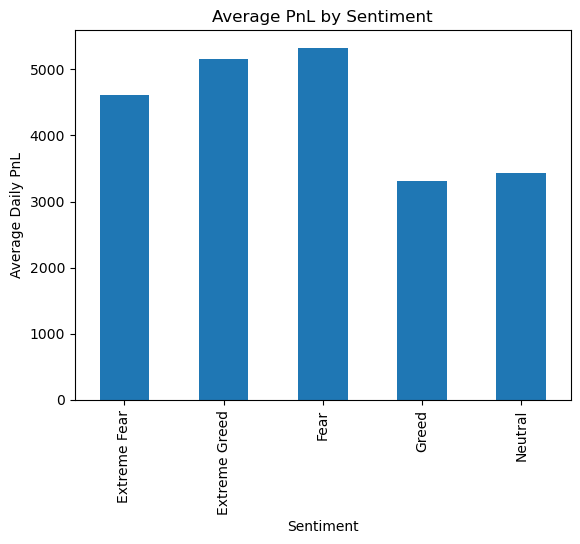

In [69]:
import matplotlib.pyplot as plt

avg_pnl_sentiment = daily_metrics.groupby(
    'classification'
)['daily_pnl'].mean()

plt.figure()

avg_pnl_sentiment.plot(kind='bar')

plt.title('Average PnL by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Daily PnL')

plt.show()

The results suggest that trader profitability is highest during Fear and Extreme Greed conditions, indicating that strong market emotions create more trading opportunities. Fear-driven markets often produce volatility and price inefficiencies that skilled traders can exploit, while Extreme Greed reflects strong bullish trends that support profitable directional trades. Interestingly, moderate Greed shows the lowest profitability, which may indicate crowded positions and reduced trading edge when market optimism becomes widespread. This pattern suggests that extreme sentiment conditions may offer better trading opportunities than stable optimistic environments.

In [62]:
daily_metrics.groupby(
    'classification'
)['daily_pnl'].describe()

,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
Extreme Fear,160.0,4619.439053,29534.839183,-77308.420095,0.0,218.377399,3381.323773,229058.684298
Extreme Greed,526.0,5161.922644,27496.863832,-132271.000000,0.0,418.319862,2385.426442,449328.107544
Fear,630.0,5328.818161,31659.771538,-108604.496278,0.0,107.892532,1807.148049,533974.662903
Greed,648.0,3318.100730,30599.040173,-358963.139984,0.0,158.214922,1319.220865,375620.270243
Neutral,376.0,3438.618818,17447.863645,-113601.020138,0.0,167.551743,1321.966347,194499.072534


Most of the median PnL values across all sentiment categories are close to zero, which means that on a typical day traders earn relatively small profits or losses. However, the average PnL is much higher because a few trades generate very large profits, especially during Fear and Extreme Greed periods. This suggests that strong emotional market conditions create larger price movements, allowing traders to capture occasional high gains. In contrast, moderate Greed and Neutral conditions show relatively lower profit potential, indicating fewer strong trading opportunities.

#### Compare percentage of profitable days across sentiment

In [64]:
daily_metrics['profitable_day'] = (
    daily_metrics['daily_pnl'] > 0
)
daily_metrics.groupby(
    'classification'
)['profitable_day'].mean().sort_values(ascending=False)

classification
Extreme Greed    0.682510
Neutral          0.622340
Greed            0.611111
Fear             0.604762
Extreme Fear     0.600000
Name: profitable_day, dtype: float64

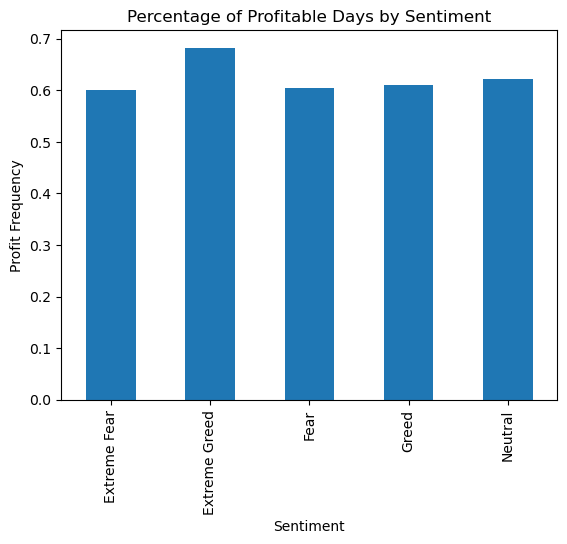

In [71]:
plt.figure()

profit_rate.plot(kind='bar')

plt.title('Percentage of Profitable Days by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Profit Frequency')

plt.show()

The percentage of profitable days shows that traders achieve the highest consistency during Extreme Greed conditions, where nearly 68% of trader-days are profitable. Although Fear conditions previously showed higher average PnL, the lower win frequency suggests that profits during Fear periods may come from fewer but larger trades. This indicates that market trends during Extreme Greed may provide more consistent opportunities, while Fear-driven markets may produce occasional high-profit opportunities due to volatility.

#### Correlation between sentiment score and pnl

In [65]:
daily_metrics[['daily_pnl','value']].corr()

,daily_pnl,value
daily_pnl,1.000000,0.000179
value,0.000179,1.000000


The correlation between sentiment value and daily PnL is close to zero, indicating no strong linear relationship between sentiment strength and trader profitability. This suggests that profits do not consistently increase as the market becomes more fearful or greedy. Instead, profitability appears to depend more on broader sentiment conditions such as Fear or Extreme Greed rather than the exact sentiment score.

#### Average pnl across trader frequency segments & sentiments

In [66]:
daily_metrics.groupby(
    'frequency_segment'
)['daily_pnl'].mean()

C:\Users\Admin\AppData\Local\Temp\ipykernel_11744\2840187389.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_metrics.groupby(


frequency_segment
infrequent    2076.602348
moderate      3780.885785
frequent      8260.048250
Name: daily_pnl, dtype: float64

In [67]:
daily_metrics.groupby(
    ['frequency_segment','classification']
)['daily_pnl'].mean()

C:\Users\Admin\AppData\Local\Temp\ipykernel_11744\1595851482.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_metrics.groupby(


frequency_segment  classification
infrequent         Extreme Fear       6200.870620
                   Extreme Greed      1913.638504
                   Fear               2662.216839
                   Greed              1504.056958
                   Neutral             496.180127
moderate           Extreme Fear       1710.496319
                   Extreme Greed      7428.986992
                   Fear               2634.524008
                   Greed              2330.562692
                   Neutral            3912.008446
frequent           Extreme Fear       7034.248565
                   Extreme Greed      5744.322508
                   Fear              11403.829670
                   Greed              8129.404415
                   Neutral            5805.939052
Name: daily_pnl, dtype: float64

C:\Users\Admin\AppData\Local\Temp\ipykernel_11744\1116669389.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  freq_pnl = daily_metrics.groupby(


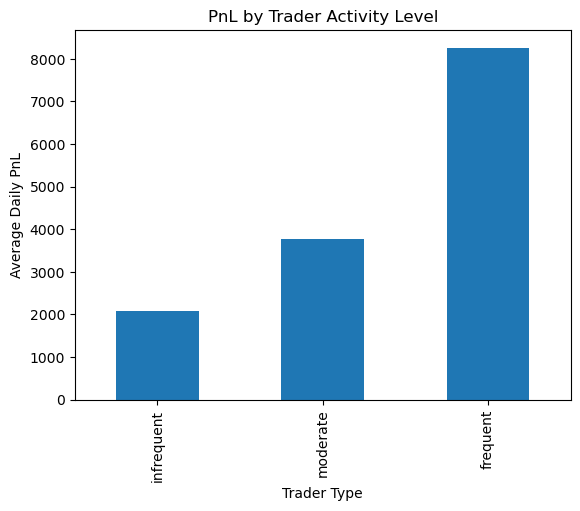

In [73]:
freq_pnl = daily_metrics.groupby(
    'frequency_segment'
)['daily_pnl'].mean()

plt.figure()

freq_pnl.plot(kind='bar')

plt.title('PnL by Trader Activity Level')
plt.xlabel('Trader Type')
plt.ylabel('Average Daily PnL')

plt.show()

Frequent traders consistently achieve higher average PnL compared to infrequent traders across most sentiment categories. The difference is particularly strong during Fear conditions, where market volatility creates more trading opportunities. This suggests that active traders may be better positioned to capture short-term price movements, while infrequent traders may miss profitable opportunities due to lower market participation. Overall, higher trading frequency appears to be associated with improved profitability across different sentiment environments.

### Overall Understanding from PnL vs Sentiment Analysis

Based on the data:

1. Profitability is higher during emotionally strong markets

Both Fear and Extreme Greed show higher average PnL compared to Neutral and Greed conditions.

This indicates that traders tend to perform better when markets exhibit strong emotional behaviour, which usually leads to:

higher volatility
stronger price movements
more trading opportunities

Strong emotions in markets often create inefficiencies that active traders can exploit.

2. Moderate Greed shows the lowest profitability

Interestingly, Greed (not extreme) shows the lowest average PnL.

This suggests:

when markets are comfortably optimistic, price movements may already reflect expectations, reducing easy profit opportunities.

Possible reasons:

trades become crowded
trends slow down
fewer mispricing opportunities
3. Large profits are driven by occasional big winning days

Median PnL values across sentiment categories are close to zero.

This means:

most trading days produce small profits or losses, while a small number of trades generate very large gains.

Hence:

overall profitability is influenced by capturing a few strong market moves.

4. Extreme Greed produces more consistent profitable days

Although Fear has slightly higher average PnL, Extreme Greed has the highest percentage of profitable days (~68%).

This suggests:

upward trending markets provide more frequent winning opportunities, even if profits per trade are not always the highest.

5. Trading frequency plays an important role

Frequent traders outperform infrequent traders across almost all sentiment regimes.

Frequent traders especially benefit during Fear markets, where volatility creates multiple short-term trading opportunities.

This indicates:

higher market participation increases the likelihood of capturing profitable price movements.

Overall Conclusion

Market sentiment influences both profit potential and trading consistency, but the relationship is not linear.

Key takeaway:

Strong emotional markets (Fear and Extreme Greed) create the best profit opportunities
Moderate optimism (Greed) shows weaker trading edge
Profits often come from a few large winning trades rather than consistent small gains
Active traders are better positioned to benefit from sentiment-driven volatility


### Actionable Strategy Insights from PnL vs Sentiment Analysis

Based on observed patterns, the following practical rules can help improve trading decisions:

#### Strategy 1 — Increase participation during high emotional markets
Insight from data

Both Fear and Extreme Greed show higher average PnL compared to Neutral and Greed conditions.

Frequent traders particularly perform well during Fear periods.

Strategy rule

Increase trading activity when market sentiment shows strong emotions (Fear or Extreme Greed).

Reason:

Strong sentiment often leads to larger price movements and short-term opportunities.

Possible application:

During Fear periods:
focus on volatility-based trades

During Extreme Greed:
focus on trend-following trades

#### Strategy 2 — Be cautious during moderate Greed markets
Insight from data

Greed sentiment shows the lowest average profitability.

This may indicate:

markets are already priced optimistically
trading opportunities become crowded
price movements slow down

Strategy rule

Avoid aggressive position sizing during moderate Greed conditions.

Instead:

focus on high-quality setups
avoid overtrading
reduce exposure if market momentum weakens

#### Strategy 3 — Focus on consistency rather than only large profits
Insight from data

Median PnL values are close to zero across sentiment categories.

This shows:

overall profitability is driven by occasional large winning trades.

Strategy rule

Maintain disciplined risk management to stay active long enough to capture high-impact trades.

Avoid:

overreacting to small losses
excessive leverage during uncertain periods

Goal:

remain consistent so that occasional strong market moves can be captured.

## Win Rate vs Sentiment

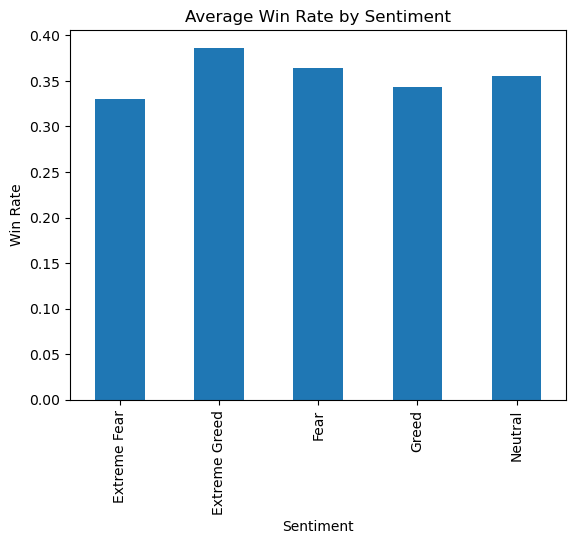

In [74]:
import matplotlib.pyplot as plt

avg_winrate = daily_metrics.groupby(
    'classification'
)['win_rate'].mean()

plt.figure()

avg_winrate.plot(kind='bar')

plt.title('Average Win Rate by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Win Rate')

plt.show()

In [75]:
daily_metrics.groupby(
    'classification'
)['win_rate'].mean().sort_values(ascending=False)

classification
Extreme Greed    0.386387
Fear             0.364033
Neutral          0.355414
Greed            0.343559
Extreme Fear     0.329659
Name: win_rate, dtype: float64

Win rate analysis indicates that traders achieve the highest consistency during Extreme Greed conditions, suggesting that strong bullish momentum creates clearer price direction and more predictable trading opportunities. Despite this, overall win rates remain below 40% across all sentiment categories, implying that traders do not rely on frequent small wins but instead depend on fewer trades that generate relatively larger profits. In contrast, Extreme Fear shows the lowest win rate, indicating that highly pessimistic market conditions are often more volatile and less predictable, leading to lower trade accuracy. Together, these results suggest that while bullish trend environments improve consistency, profitability overall is still influenced by capturing occasional high-impact trades rather than maintaining a high success rate on every trade.

#### Win Rate + Avg Trade Size

In [77]:
daily_metrics.groupby(
'classification'
)[
['win_rate','avg_trade_size']
].mean()

,win_rate,avg_trade_size
classification,,
Extreme Fear,0.329659,6773.464125
Extreme Greed,0.386387,5371.637182
Fear,0.364033,8975.928546
Greed,0.343559,6427.866594
Neutral,0.355414,6963.694861


Comparing win rate with average trade size shows that larger position sizes do not necessarily improve trade accuracy. Fear conditions exhibit the highest average trade size, indicating increased risk-taking behaviour, but win rate remains moderate due to market uncertainty. In contrast, Extreme Greed conditions show the highest win rate despite relatively smaller trade sizes, suggesting that strong bullish trends provide clearer trading signals. This indicates that trade accuracy is influenced more by market conditions than by position size alone.

### Effect of Trading Frequency on Win Rate across Sentiment

C:\Users\Admin\AppData\Local\Temp\ipykernel_11744\3649354305.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  win_freq = daily_metrics.groupby(


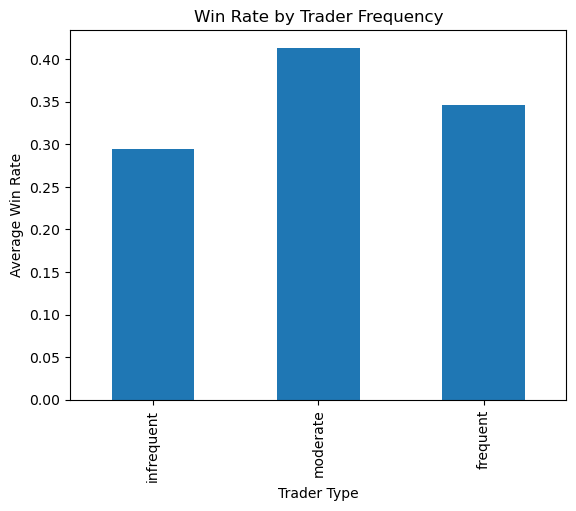

In [78]:
import matplotlib.pyplot as plt

win_freq = daily_metrics.groupby(
    'frequency_segment'
)['win_rate'].mean()

plt.figure()

win_freq.plot(kind='bar')

plt.title('Win Rate by Trader Frequency')
plt.xlabel('Trader Type')
plt.ylabel('Average Win Rate')

plt.show()

In [79]:
daily_metrics.groupby(
    ['frequency_segment','classification']
)['win_rate'].mean()

C:\Users\Admin\AppData\Local\Temp\ipykernel_11744\4265090733.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_metrics.groupby(


frequency_segment  classification
infrequent         Extreme Fear      0.291352
                   Extreme Greed     0.303159
                   Fear              0.317810
                   Greed             0.264386
                   Neutral           0.296035
moderate           Extreme Fear      0.356062
                   Extreme Greed     0.479458
                   Fear              0.401763
                   Greed             0.400794
                   Neutral           0.386156
frequent           Extreme Fear      0.327089
                   Extreme Greed     0.328845
                   Fear              0.356029
                   Greed             0.338540
                   Neutral           0.366803
Name: win_rate, dtype: float64

Analysis shows that moderate traders achieve the highest win rates across most sentiment conditions, particularly during Extreme Greed periods where trading accuracy is significantly higher. Frequent traders, despite generating higher overall profits earlier, do not exhibit the highest win rate, suggesting that their performance may come from participating in more trading opportunities rather than making more accurate predictions. Infrequent traders show the lowest win consistency, indicating that limited market participation may reduce the ability to capture profitable opportunities. Overall, balanced trading activity appears to provide better trade accuracy across different sentiment conditions.

### compare win rate across leverage segments

In [80]:
daily_metrics['leverage_segment'] = pd.qcut(

    daily_metrics['leverage_proxy'],

    q=3,

    labels=[
        'low_leverage',
        'medium_leverage',
        'high_leverage'
    ]
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_11744\2561501527.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lev_win = daily_metrics.groupby(


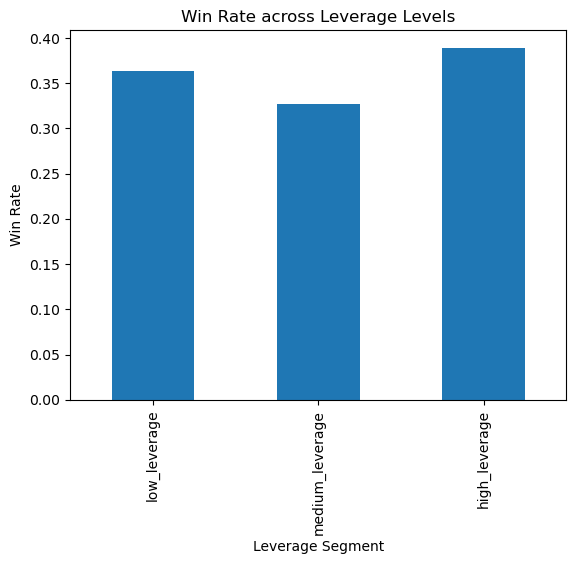

In [84]:
import matplotlib.pyplot as plt

lev_win = daily_metrics.groupby(
    'leverage_segment'
)['win_rate'].mean()

plt.figure()

lev_win.plot(kind='bar')

plt.title('Win Rate across Leverage Levels')
plt.xlabel('Leverage Segment')
plt.ylabel('Win Rate')

plt.show()

In [83]:
daily_metrics.groupby(
    ['leverage_segment','classification']
)['win_rate'].mean()

C:\Users\Admin\AppData\Local\Temp\ipykernel_11744\1922253146.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_metrics.groupby(


leverage_segment  classification
low_leverage      Extreme Fear      0.273038
                  Extreme Greed     0.415365
                  Fear              0.354718
                  Greed             0.347439
                  Neutral           0.360675
medium_leverage   Extreme Fear      0.328673
                  Extreme Greed     0.334138
                  Fear              0.351506
                  Greed             0.295497
                  Neutral           0.334093
high_leverage     Extreme Fear      0.386351
                  Extreme Greed     0.410614
                  Fear              0.384347
                  Greed             0.386023
                  Neutral           0.374667
Name: win_rate, dtype: float64

Analysis shows that traders using higher leverage tend to achieve higher win rates across most sentiment conditions, suggesting that larger position sizes may be taken when traders have stronger confidence in their trade decisions. Extreme Greed conditions provide relatively high win rates across all leverage levels, indicating that strong market trends create clearer trading opportunities. Under Extreme Fear conditions, high leverage traders perform better than low leverage traders, suggesting that experienced traders may be better able to manage risk during volatile market periods. Overall, higher leverage appears to be associated with higher trade accuracy when market sentiment is strong.

### Summary of Win Rate Analysis

Win rate analysis shows that trading accuracy varies across sentiment conditions, but overall win rates remain relatively low (around 33%–39%). This indicates that traders do not rely on frequent small wins; instead, profitability is driven by fewer but higher-impact trades.

Key Findings

1. Extreme Greed provides highest trade accuracy
Win rate is highest during Extreme Greed (~38.6%), suggesting that strong bullish trends create clearer price direction and more predictable opportunities.

2. Extreme Fear shows lowest accuracy
Win rate drops to ~33% in Extreme Fear conditions, indicating higher uncertainty, rapid reversals, and noisier price behaviour.

3. Moderate traders achieve highest win consistency
Traders with moderate activity levels show the highest win rates (up to ~48% in Extreme Greed), suggesting balanced participation improves decision quality.

4. Frequent traders generate higher profits but not highest accuracy
Frequent traders have slightly lower win rates but higher overall PnL, indicating they benefit from participating in more opportunities rather than achieving higher prediction accuracy.

5. Higher leverage is associated with higher win rate
High leverage traders show relatively better win rates across sentiment regimes, suggesting traders may increase position size when confidence in trade direction is stronger.

Strategy Insights based on Win Rate
Strategy 1 — Prefer trend-following approach during Extreme Greed

Extreme Greed conditions show highest win rate, indicating stronger directional signals.

Possible approach:

focus on momentum or trend continuation strategies during strong bullish sentiment.

Avoid counter-trend trades when sentiment is strongly positive.

Strategy 2 — Be cautious during Extreme Fear conditions

Extreme Fear shows lowest win consistency, indicating unpredictable market movements.

Possible approach:

reduce position size during high uncertainty
avoid excessive trade frequency
focus on high-confidence setups

This may reduce losses caused by false signals.

Strategy 3 — Maintain balanced trading activity

Moderate traders achieve highest win rate, suggesting that both overtrading and undertrading may reduce decision quality.

Possible approach:

avoid entering too many trades without strong signals
focus on quality setups rather than quantity of trades

Strategy 4 — Use higher exposure selectively

Higher leverage traders show relatively better win rate, suggesting that traders increase exposure when confidence is stronger.

Possible approach:

increase position size only when trade conviction is strong
avoid high exposure during uncertain sentiment regimes

## Number Of Trades Vs Sentiments

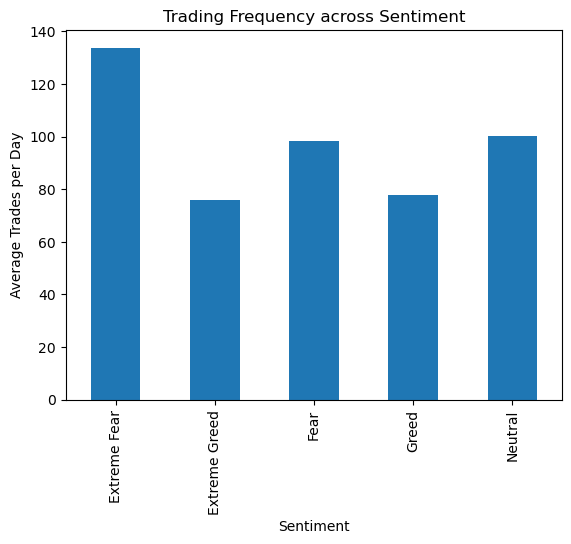

In [85]:
import matplotlib.pyplot as plt

avg_trades = daily_metrics.groupby(
'classification'
)['num_trades'].mean()

plt.figure()

avg_trades.plot(kind='bar')

plt.title('Trading Frequency across Sentiment')

plt.xlabel('Sentiment')

plt.ylabel('Average Trades per Day')

plt.show()

In [86]:
daily_metrics.groupby(
'classification'
)['num_trades'].mean().sort_values(ascending=False)

classification
Extreme Fear     133.750000
Neutral          100.228723
Fear              98.153968
Greed             77.628086
Extreme Greed     76.030418
Name: num_trades, dtype: float64

Trading frequency is highest during Extreme Fear conditions, indicating that traders become more active when markets are highly volatile and uncertain. In contrast, trading activity decreases during Greed and Extreme Greed periods, suggesting that strong trends may require fewer trades to capture profit opportunities. This shows that traders tend to increase activity in uncertain markets and adopt a more selective approach when price direction is clearer.

#### num_trades vs pnl

In [87]:
daily_metrics[['num_trades','daily_pnl']].corr()

,num_trades,daily_pnl
num_trades,1.00000,0.17562
daily_pnl,0.17562,1.00000


The correlation between number of trades and daily PnL is positive but relatively weak (0.176), indicating that trading more frequently does not strongly guarantee higher profits. While increased activity may provide more opportunities to capture profitable price movements, overall profitability appears to depend more on trade quality and market conditions rather than the sheer number of trades. This suggests that effective trading strategies focus on identifying high-quality opportunities rather than simply increasing trade frequency.

#### num_trades vs win_rate

In [88]:
daily_metrics[['num_trades','win_rate']].corr()

,num_trades,win_rate
num_trades,1.000000,0.062844
win_rate,0.062844,1.000000


The correlation between number of trades and win rate is very low (0.063), indicating that increasing trading frequency does not significantly improve trade accuracy. This suggests that trader success depends more on the quality of trading decisions rather than the number of trades executed. While higher activity may provide more opportunities to capture profits, simply trading more frequently does not necessarily lead to more consistent winning trades.

#### num_trades vs profit_per_trade

In [89]:
daily_metrics[['num_trades','profit_per_trade']].corr()

,num_trades,profit_per_trade
num_trades,1.000000,-0.025567
profit_per_trade,-0.025567,1.000000



The correlation between number of trades and profit per trade is very small (-0.026), indicating that trading frequency does not significantly affect the average profit earned per trade. This suggests that increasing the number of trades does not necessarily improve trade quality. Overall, trading performance appears to depend more on market conditions and decision quality rather than simply increasing trading activity.

### Summary — Trading Frequency (num_trades) Analysis

The analysis shows that trading activity varies significantly across sentiment conditions, but the number of trades alone does not strongly determine trading performance.

Key Findings

1. Traders are most active during Extreme Fear
The highest average number of trades occurs during Extreme Fear conditions. This suggests that traders respond to high uncertainty and volatility by increasing activity, likely attempting to capture short-term price movements or adjust positions frequently.

2. Trading activity decreases during Greed and Extreme Greed
Fewer trades are observed when market sentiment is optimistic. This indicates that strong upward trends may require fewer adjustments, as traders can hold positions longer and rely on trend continuation.

3. Trading frequency has weak relationship with performance metrics

relationship	correlation	insight
num_trades vs daily_pnl	0.176	weak positive relationship
num_trades vs win_rate	0.063	almost no relationship
num_trades vs profit_per_trade	-0.026	almost no relationship

These results show that simply trading more frequently does not strongly improve profitability, accuracy, or trade quality.

4. Trading behaviour changes with sentiment, but performance depends on trade quality
Fear-driven markets encourage higher activity due to volatility, while Greed-driven markets show lower activity due to clearer trends. However, higher activity does not necessarily improve win rate or profit per trade.

Overall Insight

Trading frequency reflects behavioural response to market sentiment rather than a direct driver of performance. Traders tend to increase activity during uncertain market conditions, but profitability depends more on identifying high-quality trading opportunities rather than simply increasing the number of trades.

Strategy Insight

Increasing trading frequency during volatile markets may provide more opportunities, but excessive trading alone does not guarantee better results. A more effective approach is to maintain disciplined trade selection and adapt activity level based on market conditions rather than reacting solely to market volatility.

### Leverage (Risk Exposure) vs Sentiment

#### visualize leverage behaviour

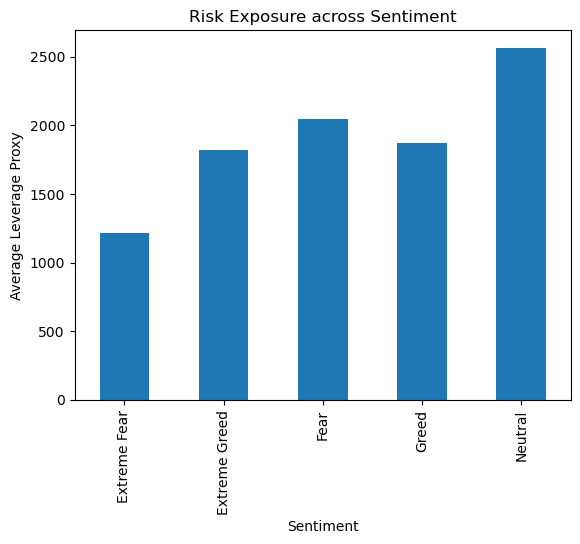

In [90]:
import matplotlib.pyplot as plt

avg_leverage = daily_metrics.groupby(
    'classification'
)['leverage_proxy'].mean()

plt.figure()

avg_leverage.plot(kind='bar')

plt.title('Risk Exposure across Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Leverage Proxy')

plt.show()

In [91]:
daily_metrics.groupby(
    'classification'
)['leverage_proxy'].mean().sort_values(ascending=False)

classification
Neutral          2565.621601
Fear             2046.069093
Greed            1869.666870
Extreme Greed    1821.246462
Extreme Fear     1215.699418
Name: leverage_proxy, dtype: float64

Leverage proxy analysis shows that traders take the highest relative exposure during Neutral market conditions, possibly to compensate for smaller price movements when market direction is unclear. In contrast, leverage decreases significantly during Extreme Fear conditions, indicating that traders reduce risk during highly uncertain environments. Moderate leverage levels are observed during Fear and Greed conditions, suggesting balanced position sizing when some directional signal is present. Overall, risk-taking behaviour appears to depend on perceived market predictability rather than emotional intensity alone.

### Long / Short Ratio vs Sentiment

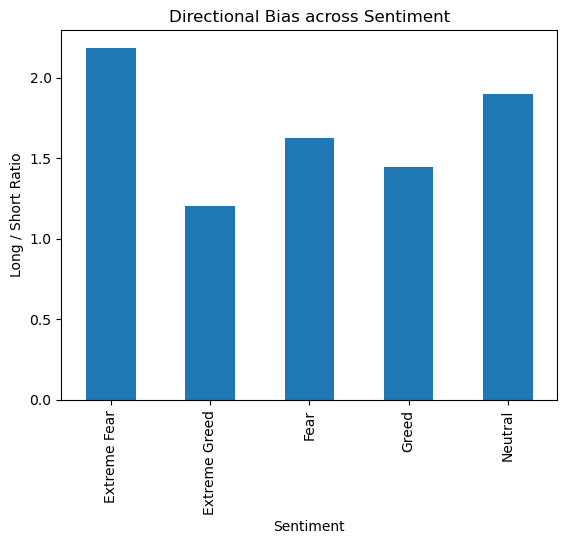

In [92]:
import matplotlib.pyplot as plt

avg_ls = daily_metrics.groupby(
    'classification'
)['long_short_ratio'].mean()

plt.figure()

avg_ls.plot(kind='bar')

plt.title('Directional Bias across Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Long / Short Ratio')

plt.show()


In [93]:
daily_metrics.groupby(
    'classification'
)['long_short_ratio'].mean().sort_values(ascending=False)

classification
Extreme Fear     2.185875
Neutral          1.900099
Fear             1.626815
Greed            1.442897
Extreme Greed    1.201754
Name: long_short_ratio, dtype: float64

Long/Short ratio analysis shows that traders generally prefer long positions across all sentiment conditions, as the ratio remains above 1 in every regime. The highest bullish bias occurs during Extreme Fear, indicating that traders tend to buy aggressively when market sentiment is highly negative, possibly expecting price recovery. As sentiment becomes more optimistic, the long bias gradually decreases, suggesting more balanced positioning or profit-taking behaviour. This indicates that traders may follow a dip-buying approach rather than increasing long exposure during highly optimistic markets.

### visualize position size behaviour

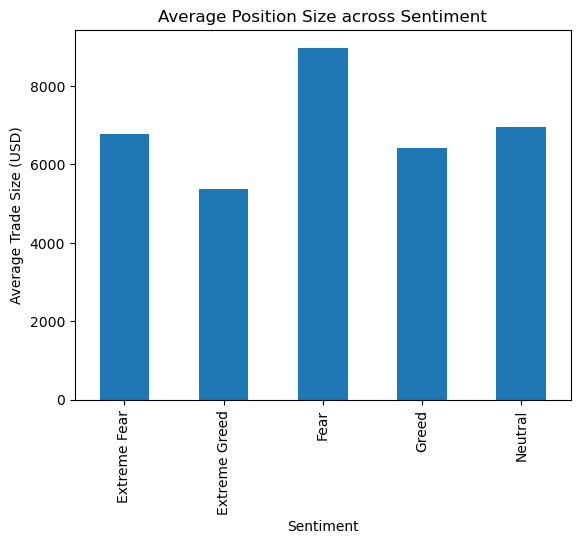

In [94]:
import matplotlib.pyplot as plt

avg_size = daily_metrics.groupby(
    'classification'
)['avg_trade_size'].mean()

plt.figure()

avg_size.plot(kind='bar')

plt.title('Average Position Size across Sentiment')

plt.xlabel('Sentiment')

plt.ylabel('Average Trade Size (USD)')

plt.show()

In [95]:
daily_metrics.groupby(
    'classification'
)['avg_trade_size'].mean().sort_values(ascending=False)

classification
Fear             8975.928546
Neutral          6963.694861
Extreme Fear     6773.464125
Greed            6427.866594
Extreme Greed    5371.637182
Name: avg_trade_size, dtype: float64

In [96]:
daily_metrics.groupby(
    'classification'
)[
    ['avg_trade_size','daily_pnl','win_rate']
].mean()

,avg_trade_size,daily_pnl,win_rate
classification,,,
Extreme Fear,6773.464125,4619.439053,0.329659
Extreme Greed,5371.637182,5161.922644,0.386387
Fear,8975.928546,5328.818161,0.364033
Greed,6427.866594,3318.100730,0.343559
Neutral,6963.694861,3438.618818,0.355414


Position size analysis indicates that traders allocate the largest capital during Fear conditions, suggesting increased willingness to take risk in volatile environments where price movements may present strong profit opportunities. Fear conditions also show the highest average PnL, indicating that larger positions can amplify gains when volatility is successfully captured. However, the highest win rate occurs during Extreme Greed conditions despite smaller average trade sizes, suggesting that strong bullish trends provide clearer and more predictable trading signals that improve trade accuracy without requiring excessive exposure. In contrast, Extreme Fear conditions show relatively high position sizes but the lowest win rate, indicating that highly uncertain markets may reduce prediction accuracy even when traders attempt to capitalize on volatility. Overall, the relationship between position size, profitability, and win rate suggests that both market opportunity and trade confidence influence how traders allocate capital under different sentiment regimes.